# Personal Expense Analyzer

## 1. Data Loading and Initial Inspection

In [53]:
import pandas as pd

In [54]:
df = pd.read_csv("../data/expenses.csv")
df

,Date,Category,Description,Amount,Payment_Method
0,2026-06-03,Food,Lunch,1098.15,Cash
1,2026-06-29,Food,Snacks,1043.84,UPI
2,2026-05-12,Entertainment,Game,1472.42,UPI
3,2026-09-01,Shopping,Clothes,6700.98,UPI
4,2026-01-03,Food,Lunch,1081.85,Cash
...,...,...,...,...,...
500,2026-09-25,Entertainment,Restaurant,672.53,Card
501,2026-04-20,Food,Coffee,1114.74,Card
502,2026-03-19,Food,Breakfast,1014.87,UPI
503,2026-08-06,Food,Lunch,110.44,Net Banking


In [55]:
df.head()

,Date,Category,Description,Amount,Payment_Method
0,2026-06-03,Food,Lunch,1098.15,Cash
1,2026-06-29,Food,Snacks,1043.84,UPI
2,2026-05-12,Entertainment,Game,1472.42,UPI
3,2026-09-01,Shopping,Clothes,6700.98,UPI
4,2026-01-03,Food,Lunch,1081.85,Cash


In [56]:
df.tail()

,Date,Category,Description,Amount,Payment_Method
500,2026-09-25,Entertainment,Restaurant,672.53,Card
501,2026-04-20,Food,Coffee,1114.74,Card
502,2026-03-19,Food,Breakfast,1014.87,UPI
503,2026-08-06,Food,Lunch,110.44,Net Banking
504,2026-07-01,Food,Coffee,825.57,Card


In [57]:
df.shape

(505, 5)

In [58]:
df.columns

Index(['Date', 'Category', 'Description', 'Amount', 'Payment_Method'], dtype='str')

In [60]:
df.describe()

,Amount
count,505.000000
mean,2043.110594
std,1854.690284
min,40.750000
25%,624.330000
50%,1181.280000
75%,3075.270000
max,7958.670000


In [61]:
df.isnull().sum()

Date              0
Category          4
Description       6
Amount            0
Payment_Method    0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(5)

In [62]:
df["Category"].unique()

<StringArray>
[         'Food', 'Entertainment',      'Shopping',        'Health',
             nan,        'Travel',     'Education',         'Bills']
Length: 8, dtype: str

In [63]:
df["Category"].value_counts(dropna=False)

Category
Food             137
Bills             82
Shopping          70
Travel            63
Entertainment     57
Education         51
Health            41
NaN                4
Name: count, dtype: int64

In [64]:
df["Payment_Method"].value_counts()

Payment_Method
UPI            249
Card           121
Cash            89
Net Banking     46
Name: count, dtype: int64

In [65]:
df["Description"].value_counts(dropna=False).head(20)

Description
Dinner                 25
Groceries              24
Snacks                 23
Electronics            23
Coffee                 23
Breakfast              22
Mobile Bill            20
Lunch                  19
Gas Bill               17
Exam Fee               16
Rent                   15
Restaurant             15
Internet Bill          15
Household Items        15
Electricity Bill       15
Doctor Consultation    13
Movie                  13
Accessories            12
Dental                 12
Train                  12
Name: count, dtype: int64

In [66]:
df["Date"] = pd.to_datetime(df["Date"])

In [67]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            505 non-null    datetime64[us]
 1   Category        501 non-null    str           
 2   Description     499 non-null    str           
 3   Amount          505 non-null    float64       
 4   Payment_Method  505 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 19.9 KB


In [68]:
df[df["Description"].isnull()]

,Date,Category,Description,Amount,Payment_Method
6,2026-03-04,Entertainment,NaN,1162.84,UPI
122,2026-08-23,Food,NaN,422.50,Cash
140,2026-04-05,Food,NaN,320.33,UPI
173,2026-05-28,Entertainment,NaN,2319.28,Card
202,2026-03-26,Food,NaN,460.22,Net Banking
323,2026-07-21,Food,NaN,989.43,UPI


In [69]:
df["Description"] = df["Description"].fillna("Unknown")

In [70]:
df["Description"].isnull().sum()

np.int64(0)

In [71]:
df[df["Category"].isnull()]

,Date,Category,Description,Amount,Payment_Method
7,2026-03-15,NaN,Lunch,1024.82,Cash
120,2026-09-23,NaN,Electronics,4348.71,UPI
295,2026-05-15,NaN,Dinner,188.43,Net Banking
348,2026-03-13,NaN,Coffee,1091.24,Net Banking


In [72]:
df[df["Category"].isnull()][
    ["Date", "Description", "Amount", "Payment_Method"]
]

,Date,Description,Amount,Payment_Method
7,2026-03-15,Lunch,1024.82,Cash
120,2026-09-23,Electronics,4348.71,UPI
295,2026-05-15,Dinner,188.43,Net Banking
348,2026-03-13,Coffee,1091.24,Net Banking


In [73]:
df[df.duplicated(keep=False)].sort_values(
    by=["Date", "Amount"]
)

,Date,Category,Description,Amount,Payment_Method
23,2026-02-10,Food,Groceries,1101.94,Cash
157,2026-02-10,Food,Groceries,1101.94,Cash
39,2026-07-08,Education,Books,4249.16,Net Banking
462,2026-07-08,Education,Books,4249.16,Net Banking
32,2026-07-30,Health,Pharmacy,1836.22,Card
93,2026-07-30,Health,Pharmacy,1836.22,Card
76,2026-08-22,Food,Snacks,301.99,Net Banking
496,2026-08-22,Food,Snacks,301.99,Net Banking
98,2026-09-20,Bills,Mobile Bill,5920.47,UPI
128,2026-09-20,Bills,Mobile Bill,5920.47,UPI


In [74]:
df.loc[df["Description"] == "Lunch", "Category"] = "Food"

df.loc[df["Description"] == "Electronics", "Category"] = "Shopping"

df.loc[df["Description"] == "Dinner", "Category"] = "Food"

df.loc[df["Description"] == "Coffee", "Category"] = "Food"

In [75]:
df["Category"].isnull().sum()

np.int64(0)

In [76]:
df[df["Category"].isnull()]

,Date,Category,Description,Amount,Payment_Method


In [77]:
df.shape

(505, 5)

In [78]:
df = df.drop_duplicates()

In [79]:
df.shape

(500, 5)

In [80]:
df.duplicated().sum()

np.int64(0)

In [81]:
df.isnull().sum()

Date              0
Category          0
Description       0
Amount            0
Payment_Method    0
dtype: int64

In [82]:
df.info()

<class 'pandas.DataFrame'>
Index: 500 entries, 0 to 504
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            500 non-null    datetime64[us]
 1   Category        500 non-null    str           
 2   Description     500 non-null    str           
 3   Amount          500 non-null    float64       
 4   Payment_Method  500 non-null    str           
dtypes: datetime64[us](1), float64(1), str(3)
memory usage: 23.4 KB


In [83]:
df.shape

(500, 5)

In [84]:
df.to_csv("../data/cleaned_expenses.csv", index=False)

## 2. Expense Analysis

In [85]:
total_expense = df["Amount"].sum()
print("Total Expense:", total_expense)

Total Expense: 1018361.0700000001


In [86]:
average_expense = df["Amount"].mean()
print(f"Average Expense: ₹{average_expense:,.2f}")

Average Expense: ₹2,036.72


In [88]:
highest_transaction = df.loc[df["Amount"].idxmax()]
print(highest_transaction)

Date              2026-08-24 00:00:00
Category                     Shopping
Description               Electronics
Amount                        7958.67
Payment_Method                   Card
Name: 242, dtype: object


In [89]:
lowest_transaction = df.loc[df["Amount"].idxmin()]
print(lowest_transaction)

Date              2026-02-08 00:00:00
Category                       Travel
Description                       Cab
Amount                          40.75
Payment_Method                    UPI
Name: 134, dtype: object


In [90]:
category_expense = df.groupby("Category")["Amount"].sum()
print(category_expense)

Category
Bills            290557.53
Education        142436.30
Entertainment     79601.23
Food              89295.27
Health            96558.23
Shopping         275712.27
Travel            44200.24
Name: Amount, dtype: float64


In [91]:
category_expense = (
    df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)
print(category_expense)

Category
Bills            290557.53
Shopping         275712.27
Education        142436.30
Health            96558.23
Food              89295.27
Entertainment     79601.23
Travel            44200.24
Name: Amount, dtype: float64


In [92]:
highest_category = category_expense.idxmax()
highest_category_amount = category_expense.max()
print(f"Highest Spending Category: {highest_category}")
print(f"Amount Spent: ₹{highest_category_amount:,.2f}")

Highest Spending Category: Bills
Amount Spent: ₹290,557.53


In [93]:
payment_expense = (
    df.groupby("Payment_Method")["Amount"]
    .sum()
    .sort_values(ascending=False)
)
print(payment_expense)

Payment_Method
UPI            490947.94
Card           249272.14
Cash           190811.78
Net Banking     87329.21
Name: Amount, dtype: float64


In [94]:
highest_payment_spending = payment_expense.idxmax()
print(highest_payment_spending)

UPI


In [95]:
payment_count = df["Payment_Method"].value_counts()
print(payment_count)

Payment_Method
UPI            248
Card           120
Cash            88
Net Banking     44
Name: count, dtype: int64


In [96]:
most_used_payment = payment_count.idxmax()
print("Most Used Payment Method:", most_used_payment)

Most Used Payment Method: UPI


In [97]:
monthly_expense = (
    df.groupby(df["Date"].dt.to_period("M"))["Amount"]
    .sum()
)
print(monthly_expense)

Date
2026-01    102122.65
2026-02     99432.62
2026-03    112237.37
2026-04    104425.89
2026-05    127611.27
2026-06    113566.12
2026-07    140080.84
2026-08     88917.27
2026-09    129967.04
Freq: M, Name: Amount, dtype: float64


In [98]:
highest_month = monthly_expense.idxmax()
highest_month_amount = monthly_expense.max()
print("Highest Spending Month:", highest_month)
print(f"Amount: ₹{highest_month_amount:,.2f}")

Highest Spending Month: 2026-07
Amount: ₹140,080.84


In [99]:
total_expense = df["Amount"].sum()

In [100]:
number_of_days = (df["Date"].max() - df["Date"].min()).days + 1

In [101]:
average_daily_expense = total_expense / number_of_days
print(f"Average Daily Expense: ₹{average_daily_expense:,.2f}")

Average Daily Expense: ₹3,730.26


In [102]:
high_expenses = df[df["Amount"] > 5000]
print(high_expenses)

          Date  Category       Description   Amount Payment_Method
3   2026-09-01  Shopping           Clothes  6700.98            UPI
31  2026-07-30     Bills     Internet Bill  5063.62           Cash
34  2026-06-11  Shopping   Household Items  5926.34            UPI
49  2026-06-28     Bills       Mobile Bill  5222.29           Card
54  2026-02-18  Shopping   Household Items  6861.08            UPI
66  2026-01-19     Bills          Gas Bill  5971.53           Card
73  2026-04-16  Shopping       Electronics  7211.59    Net Banking
79  2026-07-15     Bills          Gas Bill  5482.46    Net Banking
98  2026-09-20     Bills       Mobile Bill  5920.47            UPI
100 2026-09-30     Bills              Rent  5703.15            UPI
112 2026-03-07  Shopping   Household Items  7715.92           Card
129 2026-05-04     Bills  Electricity Bill  5078.91            UPI
144 2026-06-08     Bills     Internet Bill  5093.19            UPI
152 2026-07-11     Bills     Internet Bill  5838.84           

In [103]:
print("Number of expenses above ₹5,000:", len(high_expenses))

Number of expenses above ₹5,000: 46


In [104]:
top_10_expenses = df.nlargest(10, "Amount")
print(top_10_expenses)

          Date  Category      Description   Amount Payment_Method
242 2026-08-24  Shopping      Electronics  7958.67           Card
481 2026-03-03  Shopping  Household Items  7800.45            UPI
245 2026-05-25  Shopping      Electronics  7772.90            UPI
410 2026-09-28  Shopping          Clothes  7756.27            UPI
112 2026-03-07  Shopping  Household Items  7715.92           Card
334 2026-07-03  Shopping      Electronics  7515.05           Cash
185 2026-01-03  Shopping      Accessories  7495.97            UPI
241 2026-09-26  Shopping      Accessories  7245.96           Card
73  2026-04-16  Shopping      Electronics  7211.59    Net Banking
324 2026-09-22  Shopping  Household Items  7155.08           Card


In [106]:
category_count = df["Category"].value_counts()
print(category_count)

Category
Food             138
Bills             81
Shopping          71
Travel            63
Entertainment     57
Education         50
Health            40
Name: count, dtype: int64


In [107]:
category_result = (
    df.groupby("Category")["Amount"]
    .sum()
    .reset_index()
)
category_result.columns = ["Category", "Total_Expense"]

In [108]:
category_result.to_csv(
    "../results/category_expense.csv",
    index=False
)

In [109]:
import matplotlib.pyplot as plt

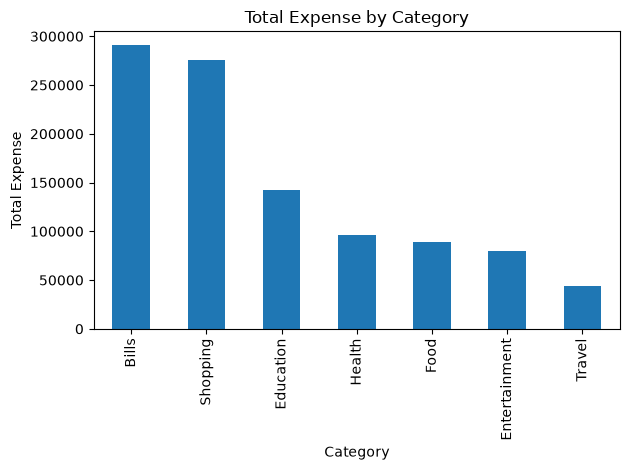

In [110]:
category_expense = (
    df.groupby("Category")["Amount"]
    .sum()
    .sort_values(ascending=False)
)
category_expense.plot(kind="bar")
plt.title("Total Expense by Category")
plt.xlabel("Category")
plt.ylabel("Total Expense")
plt.tight_layout()
plt.savefig("../results/category_expense.png")
plt.show()

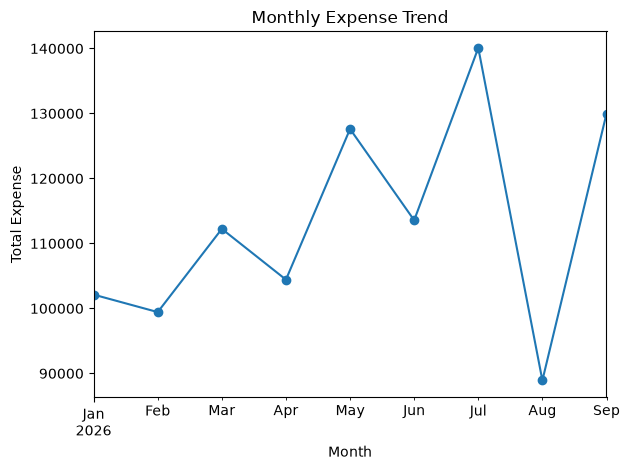

In [111]:
monthly_expense = (
    df.groupby(df["Date"].dt.to_period("M"))["Amount"]
    .sum()
)
monthly_expense.plot(kind="line", marker="o")
plt.title("Monthly Expense Trend")
plt.xlabel("Month")
plt.ylabel("Total Expense")
plt.tight_layout()
plt.savefig("../results/monthly_expense.png")
plt.show()